In [38]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns



In [39]:
dt= pd.read_csv("train.csv")
dt

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,Expected,Id
0,0,143733,False,0.439,0.196,0,-16.093,1,0.0601,0.880000,0.00000,0.0513,0.525,129.581,4,jazz,4271
1,0,261562,False,0.627,0.876,11,-4.391,0,0.0324,0.015900,0.00000,0.0665,0.418,111.950,4,electronic,2078
2,63,190131,False,0.767,0.869,2,-3.381,0,0.0908,0.140000,0.00000,0.2210,0.751,98.208,4,hip-hop,4921
3,48,201440,False,0.374,0.183,9,-13.225,1,0.0281,0.897000,0.03870,0.1090,0.134,82.042,4,acoustic,4206
4,0,168552,True,0.423,0.721,0,-8.070,1,0.1650,0.007920,0.00000,0.3800,0.382,161.926,4,rock,2423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4195,38,451750,False,0.764,0.873,10,-7.985,0,0.0466,0.000117,0.74400,0.6150,0.169,124.025,4,electronic,5157
4196,64,182640,True,0.598,0.804,2,-5.390,1,0.1230,0.057600,0.00000,0.2520,0.322,139.737,4,hip-hop,1084
4197,82,354320,False,0.414,0.404,0,-9.928,0,0.0499,0.271000,0.00000,0.3000,0.224,71.105,4,rock,2288
4198,0,192160,False,0.320,0.210,6,-15.231,1,0.0345,0.920000,0.00008,0.1380,0.208,73.196,5,jazz,1824


In [40]:
#vemos los NaN
dt.isna().mean()

popularity          0.0
duration_ms         0.0
explicit            0.0
danceability        0.0
energy              0.0
key                 0.0
loudness            0.0
mode                0.0
speechiness         0.0
acousticness        0.0
instrumentalness    0.0
liveness            0.0
valence             0.0
tempo               0.0
time_signature      0.0
Expected            0.0
Id                  0.0
dtype: float64

In [41]:
#vemos tipo de datos
dt.dtypes

popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
Expected                str
Id                    int64
dtype: object

In [42]:
#hacemos label encoding para Expected
le = LabelEncoder()
le.classes_ = np.array(["rock", "jazz", 'electronic', 'hip-hop', 'acoustic', 'classical'])
dt["Expected"] = le.transform(dt["Expected"])
dt["Expected"].head()

0    1
1    2
2    3
3    4
4    0
Name: Expected, dtype: int64

In [43]:
cantidad_falsos_acoustic = ((dt["explicit"] == 0) & (dt["Expected"]== 4)).sum()
cantidad_explicit_acoustic = (dt["Expected"] == 4).sum()
ratio_explicit_acoustic = cantidad_falsos_acoustic / cantidad_explicit_acoustic
ratio_explicit_acoustic

np.float64(0.9442857142857143)

In [44]:
#vemos ratios que consideramos interesantes para diferenciar generos.
cantidad_falsos_jaz = ((dt["explicit"] == 0) & (dt["Expected"]== 1)).sum()
cantidad_explicit_jaz = (dt["Expected"] == 1).sum()
ratio_explicit = cantidad_falsos_jaz / cantidad_explicit_jaz
ratio_explicit
#podemos ver como el genero de jaz tiene en su mayoría imagenes no explcitas.

np.float64(0.9971428571428571)

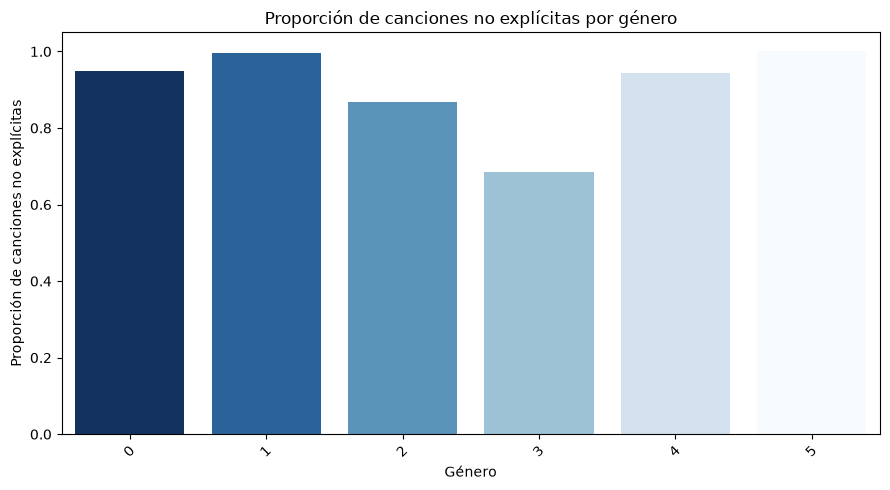

In [45]:
ratio_no_explicitas = (
    dt.groupby("Expected")["explicit"]
      .apply(lambda columna: (~columna).mean())
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=ratio_no_explicitas.index,
    y=ratio_no_explicitas.values,
    hue=ratio_no_explicitas.index,
    palette="Blues_r",
    legend=False
)

plt.title("Proporción de canciones no explícitas por género")
plt.xlabel("Género")
plt.ylabel("Proporción de canciones no explícitas")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#este grafico muestra como el genero de jaz se destaca en ser el genero con menor contenido explicito

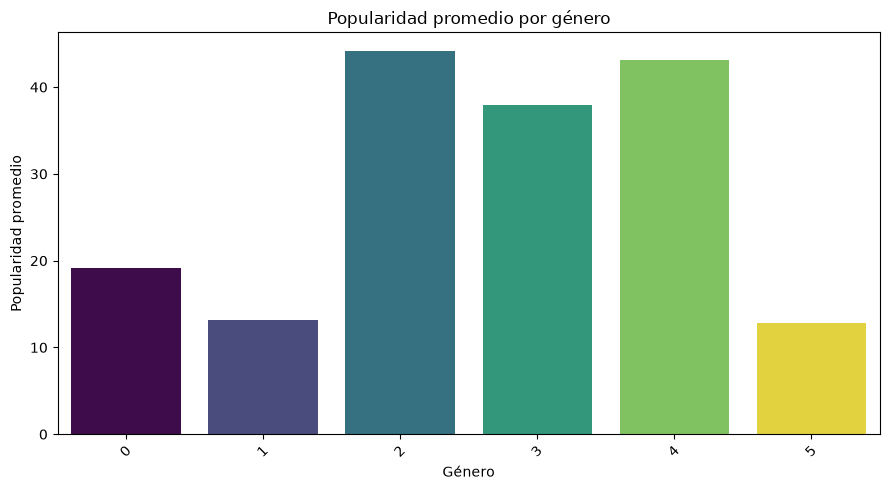

In [46]:

popularidad_genero = (
    dt.groupby("Expected")["popularity"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=popularidad_genero.index,
    y=popularidad_genero.values,
    hue=popularidad_genero.index,
    palette="viridis",
    legend=False
)

plt.title("Popularidad promedio por género")
plt.xlabel("Género")
plt.ylabel("Popularidad promedio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

podemos notar que el genero de electronica y acustico se destacan a diferencia de los otros en la popularidad.

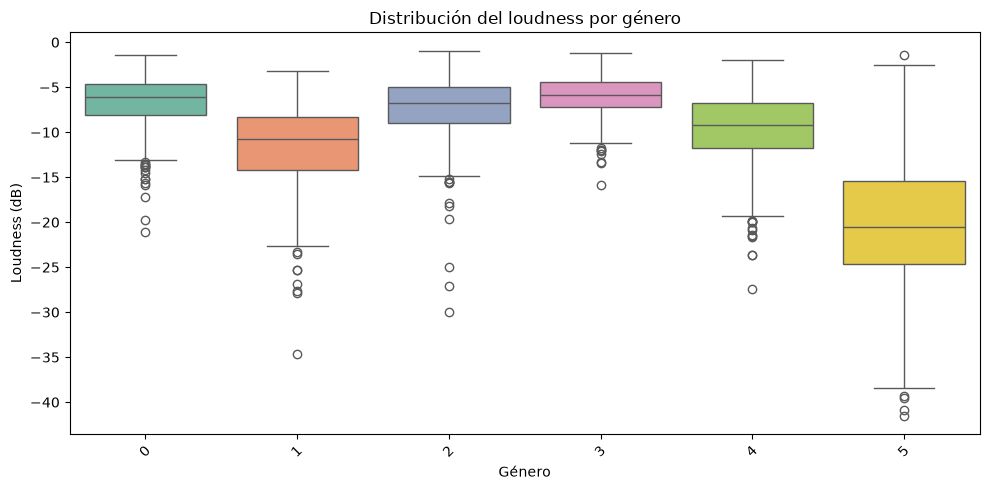

In [47]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=dt,
    x="Expected",
    y="loudness",
    hue="Expected",
    palette="Set2",
    legend=False
)

plt.title("Distribución del loudness por género")
plt.xlabel("Género")
plt.ylabel("Loudness (dB)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()